In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule

In [14]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='16', run_id='1f14e9ebe6564fb28a9d278bf35200bf')

Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:16//data/model.pt2


In [15]:
model.predict(torch.randn(1,3,512,256))

(1147.017822265625,
 tensor([[[0.0059, 0.0063, 0.0072,  ..., 0.0107, 0.0090, 0.0082],
          [0.0066, 0.0071, 0.0081,  ..., 0.0122, 0.0103, 0.0093],
          [0.0081, 0.0087, 0.0099,  ..., 0.0151, 0.0128, 0.0116],
          ...,
          [0.0065, 0.0071, 0.0083,  ..., 0.0057, 0.0045, 0.0039],
          [0.0049, 0.0054, 0.0063,  ..., 0.0039, 0.0031, 0.0027],
          [0.0042, 0.0045, 0.0052,  ..., 0.0030, 0.0024, 0.0021]]],
        device='cuda:0'))

In [16]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='fit')

In [20]:
sample, target, count = helpers.get_sample_from_dm(datamodule)
sample.shape

torch.Size([1, 3, 672, 992])

In [21]:
result_count, result  = model.predict(sample)
(result_count, result)

(894.6751708984375,
 tensor([[[8.0608e-04, 7.7854e-04, 7.2535e-04,  ..., 1.4099e-04,
           1.9768e-04, 2.3318e-04],
          [8.2812e-04, 7.9553e-04, 7.3291e-04,  ..., 1.0182e-04,
           1.5326e-04, 1.8722e-04],
          [8.7334e-04, 8.3023e-04, 7.4819e-04,  ..., 5.2318e-05,
           9.0858e-05, 1.1918e-04],
          ...,
          [1.3368e-04, 9.3054e-05, 4.4339e-05,  ..., 2.3206e-05,
           4.8454e-05, 6.9709e-05],
          [1.9379e-04, 1.4722e-04, 8.3657e-05,  ..., 5.2084e-05,
           9.4099e-05, 1.2579e-04],
          [2.3228e-04, 1.8421e-04, 1.1427e-04,  ..., 7.7593e-05,
           1.3024e-04, 1.6775e-04]]], device='cuda:0'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


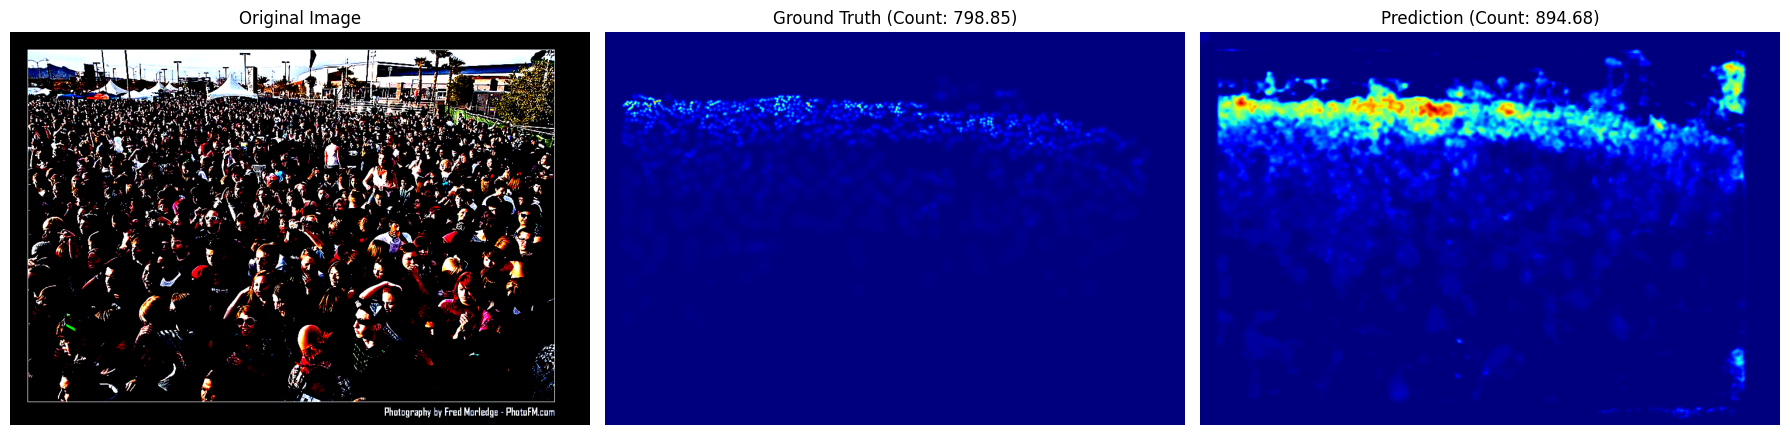

In [22]:
vis.visualize_sample(sample, target, result, count, result_count, )